<a href="https://colab.research.google.com/github/shreeyasharma1804/notes/blob/main/deepLearning/WeatherForecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

In [2]:
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
csv_path = os.path.join(zip_path, "jena_climate_2009_2016.csv")

In [15]:
df = pd.read_csv(csv_path)
print(df.head())

             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

In [16]:
date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')
print(date_time.head())

0   2009-01-01 00:10:00
1   2009-01-01 00:20:00
2   2009-01-01 00:30:00
3   2009-01-01 00:40:00
4   2009-01-01 00:50:00
Name: Date Time, dtype: datetime64[ns]


In [17]:
print(df.head())

   p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  VPmax (mbar)  \
0    996.52     -8.02    265.40        -8.90    93.3          3.33   
1    996.57     -8.41    265.01        -9.28    93.4          3.23   
2    996.53     -8.51    264.91        -9.31    93.9          3.21   
3    996.51     -8.31    265.12        -9.07    94.2          3.26   
4    996.51     -8.27    265.15        -9.04    94.1          3.27   

   VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  rho (g/m**3)  \
0          3.11          0.22       1.94             3.12       1307.75   
1          3.02          0.21       1.89             3.03       1309.80   
2          3.01          0.20       1.88             3.02       1310.24   
3          3.07          0.19       1.92             3.08       1309.19   
4          3.08          0.19       1.92             3.09       1309.00   

   wv (m/s)  max. wv (m/s)  wd (deg)  
0      1.03           1.75     152.3  
1      0.72           1.50     136.1  
2      0.19

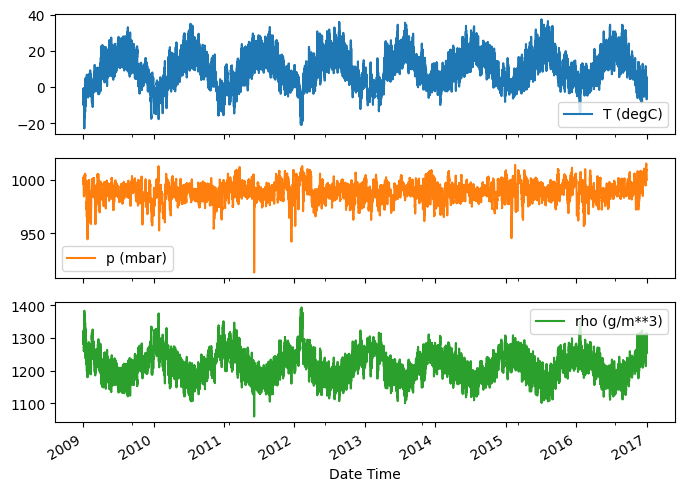

In [18]:
plot_cols = ['T (degC)', 'p (mbar)', 'rho (g/m**3)']
plot_features = df[plot_cols]
plot_features.index = date_time
_ = plot_features.plot(subplots=True)

In [19]:
wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')

# Convert to radians.
wd_rad = df.pop('wd (deg)')*np.pi / 180

# Calculate the wind x and y components.
df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)

# Calculate the max wind x and y components.
df['max Wx'] = max_wv*np.cos(wd_rad)
df['max Wy'] = max_wv*np.sin(wd_rad)

In [21]:
column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

In [24]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

In [25]:
train_data = train_df.values
val_data = val_df.values
test_data = test_df.values

In [26]:
INPUT_WIDTH = 24

def make_dataset(data):
    X = []
    y = []

    for i in range(len(data) - INPUT_WIDTH):
        X.append(data[i:i + INPUT_WIDTH])
        y.append(data[i + INPUT_WIDTH])

    return np.array(X), np.array(y)

In [27]:
X_train, y_train = make_dataset(train_data)
X_val, y_val = make_dataset(val_data)
X_test, y_test = make_dataset(test_data)

In [28]:
print(X_train.shape, y_train.shape)

(294361, 24, 15) (294361, 15)


In [ ]:
# RNN Training

model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(
        units=64,
        activation='tanh'
    ),
    tf.keras.layers.Dense(15)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# The output of an RNN cell is its feedback value

In [ ]:
# LSTM Training

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)


model = tf.keras.Sequential([
    tf.keras.layers.LSTM(
        units=64,
        activation='tanh'
    ),
    tf.keras.layers.Dense(15)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train,
    y_train,
    epochs=2,
    batch_size=32,
    validation_split=0.2,
    callbacks = [tensorboard_callback]
)